In [ ]:
from google.colab import files
import zipfile
import os

uploaded = files.upload()

zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('/content/mediscan_dataset')

print("Dataset extracted successfully!")

TypeError: 'NoneType' object is not subscriptable

In [ ]:
import os

base_path = "/content/mediscan_dataset/Doctor’s Handwritten Prescription BD dataset"

for root, dirs, files in os.walk(base_path):
    level = root.replace(base_path, '').count(os.sep)
    indent = ' ' * 4 * level
    print(indent + os.path.basename(root) + '/')

    if level < 2:
        for file in files[:5]:
            print(indent + '    ' + file)

Doctor’s Handwritten Prescription BD dataset/
    Validation/
        validation_labels.csv
        validation_words/
    Training/
        training_labels.csv
        training_words/
    Testing/
        testing_labels.csv
        testing_words/


In [ ]:
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
train_csv = os.path.join(base_path, "Training", "training_labels.csv")
val_csv = os.path.join(base_path, "Validation", "validation_labels.csv")
test_csv = os.path.join(base_path, "Testing", "testing_labels.csv")

train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)
test_df = pd.read_csv(test_csv)

print("Training:", train_df.shape)
print("Validation:", val_df.shape)
print("Testing:", test_df.shape)

Training: (3120, 3)
Validation: (780, 3)
Testing: (780, 3)


In [ ]:
print("Training data:")
display(train_df.head())

print("\nColumns:")
print(train_df.columns)

print("\nMissing values:")
print(train_df.isnull().sum())

Training data:


,IMAGE,MEDICINE_NAME,GENERIC_NAME
0,0.png,Aceta,Paracetamol
1,1.png,Aceta,Paracetamol
2,2.png,Aceta,Paracetamol
3,3.png,Aceta,Paracetamol
4,4.png,Aceta,Paracetamol



Columns:
Index(['IMAGE', 'MEDICINE_NAME', 'GENERIC_NAME'], dtype='object')

Missing values:
IMAGE            0
MEDICINE_NAME    0
GENERIC_NAME     0
dtype: int64


In [ ]:
train_df = train_df.dropna()
val_df = val_df.dropna()
test_df = test_df.dropna()

train_df = train_df.drop_duplicates()
val_df = val_df.drop_duplicates()
test_df = test_df.drop_duplicates()

print("Training after cleaning:", train_df.shape)
print("Validation after cleaning:", val_df.shape)
print("Testing after cleaning:", test_df.shape)

Training after cleaning: (3120, 3)
Validation after cleaning: (780, 3)
Testing after cleaning: (780, 3)


In [ ]:
train_img_dir = os.path.join(base_path, "Training", "training_words")
val_img_dir = os.path.join(base_path, "Validation", "validation_words")
test_img_dir = os.path.join(base_path, "Testing", "testing_words")

train_df["image_path"] = train_df["IMAGE"].apply(
    lambda x: os.path.join(train_img_dir, x)
)

val_df["image_path"] = val_df["IMAGE"].apply(
    lambda x: os.path.join(val_img_dir, x)
)

test_df["image_path"] = test_df["IMAGE"].apply(
    lambda x: os.path.join(test_img_dir, x)
)

print(train_df.head())

   IMAGE MEDICINE_NAME GENERIC_NAME  \
0  0.png         Aceta  Paracetamol   
1  1.png         Aceta  Paracetamol   
2  2.png         Aceta  Paracetamol   
3  3.png         Aceta  Paracetamol   
4  4.png         Aceta  Paracetamol   

                                          image_path  
0  /content/mediscan_dataset/Doctor’s Handwritten...  
1  /content/mediscan_dataset/Doctor’s Handwritten...  
2  /content/mediscan_dataset/Doctor’s Handwritten...  
3  /content/mediscan_dataset/Doctor’s Handwritten...  
4  /content/mediscan_dataset/Doctor’s Handwritten...  


In [ ]:
train_df["exists"] = train_df["image_path"].apply(os.path.exists)
val_df["exists"] = val_df["image_path"].apply(os.path.exists)
test_df["exists"] = test_df["image_path"].apply(os.path.exists)

print("Missing training images:", (~train_df["exists"]).sum())
print("Missing validation images:", (~val_df["exists"]).sum())
print("Missing testing images:", (~test_df["exists"]).sum())

Missing training images: 0
Missing validation images: 0
Missing testing images: 0


In [ ]:
train_df = train_df[train_df["exists"]].copy()
val_df = val_df[val_df["exists"]].copy()
test_df = test_df[test_df["exists"]].copy()

train_df.drop(columns=["exists"], inplace=True)
val_df.drop(columns=["exists"], inplace=True)
test_df.drop(columns=["exists"], inplace=True)

In [ ]:
IMG_SIZE = (128, 64)

def preprocess_image(image_path):
    # Read image
    image = cv2.imread(image_path)

    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Resize image
    gray = cv2.resize(gray, IMG_SIZE)

    # Noise removal
    gray = cv2.GaussianBlur(gray, (3, 3), 0)

    # Binary threshold
    _, binary = cv2.threshold(
        gray, 0, 255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # Normalize pixels between 0 and 1
    normalized = binary.astype(np.float32) / 255.0

    return normalized

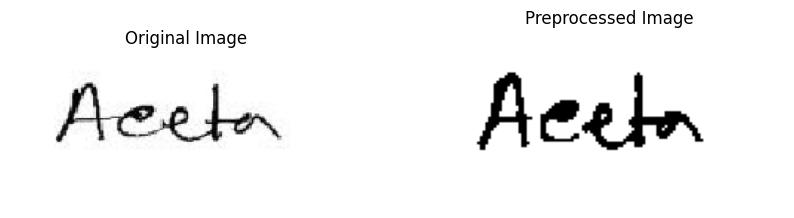

In [ ]:
sample_path = train_df.iloc[0]["image_path"]

original = cv2.imread(sample_path)
original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

processed = preprocess_image(sample_path)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(original)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(processed, cmap="gray")
plt.title("Preprocessed Image")
plt.axis("off")

plt.show()

In [ ]:
X_train = []
y_train = []

for _, row in train_df.iterrows():
    image = preprocess_image(row["image_path"])
    X_train.append(image)
    y_train.append(row["MEDICINE_NAME"])

X_train = np.array(X_train)
y_train = np.array(y_train)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (3120, 64, 128)
y_train shape: (3120,)


In [ ]:
X_val = []
y_val = []

for _, row in val_df.iterrows():
    image = preprocess_image(row["image_path"])
    X_val.append(image)
    y_val.append(row["MEDICINE_NAME"])

X_val = np.array(X_val)
y_val = np.array(y_val)

print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

X_val shape: (780, 64, 128)
y_val shape: (780,)


In [ ]:
X_test = []
y_test = []

for _, row in test_df.iterrows():
    image = preprocess_image(row["image_path"])
    X_test.append(image)
    y_test.append(row["MEDICINE_NAME"])

X_test = np.array(X_test)
y_test = np.array(y_test)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (780, 64, 128)
y_test shape: (780,)


In [ ]:
X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("Training shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Testing shape:", X_test.shape)

Training shape: (3120, 64, 128, 1)
Validation shape: (780, 64, 128, 1)
Testing shape: (780, 64, 128, 1)


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)

y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

print("Number of medicine classes:", len(label_encoder.classes_))

print("\nMedicine classes:")
print(label_encoder.classes_)

Number of medicine classes: 78

Medicine classes:
['Ace' 'Aceta' 'Alatrol' 'Amodis' 'Atrizin' 'Axodin' 'Az' 'Azithrocin'
 'Azyth' 'Bacaid' 'Backtone' 'Baclofen' 'Baclon' 'Bacmax' 'Beklo'
 'Bicozin' 'Canazole' 'Candinil' 'Cetisoft' 'Conaz' 'Dancel' 'Denixil'
 'Diflu' 'Dinafex' 'Disopan' 'Esonix' 'Esoral' 'Etizin' 'Exium' 'Fenadin'
 'Fexo' 'Fexofast' 'Filmet' 'Fixal' 'Flamyd' 'Flexibac' 'Flexilax'
 'Flugal' 'Ketocon' 'Ketoral' 'Ketotab' 'Ketozol' 'Leptic' 'Lucan-R'
 'Lumona' 'M-Kast' 'Maxima' 'Maxpro' 'Metro' 'Metsina' 'Monas' 'Montair'
 'Montene' 'Montex' 'Napa' 'Napa Extend' 'Nexcap' 'Nexum' 'Nidazyl'
 'Nizoder' 'Odmon' 'Omastin' 'Opton' 'Progut' 'Provair' 'Renova' 'Rhinil'
 'Ritch' 'Rivotril' 'Romycin' 'Rozith' 'Sergel' 'Tamen' 'Telfast'
 'Tridosil' 'Trilock' 'Vifas' 'Zithrin']


In [ ]:
np.save("/content/X_train.npy", X_train)
np.save("/content/y_train.npy", y_train_encoded)

np.save("/content/X_val.npy", X_val)
np.save("/content/y_val.npy", y_val_encoded)

np.save("/content/X_test.npy", X_test)
np.save("/content/y_test.npy", y_test_encoded)

np.save(
    "/content/medicine_classes.npy",
    label_encoder.classes_
)

print("Preprocessed data saved successfully!")

Preprocessed data saved successfully!


In [ ]:
print("========== FINAL PREPROCESSED DATA ==========")

print("X_train:", X_train.shape)
print("y_train:", y_train_encoded.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val_encoded.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test_encoded.shape)

print("Medicine classes:", len(label_encoder.classes_))

========== FINAL PREPROCESSED DATA ==========
X_train: (3120, 64, 128, 1)
y_train: (3120,)
X_val: (780, 64, 128, 1)
y_val: (780,)
X_test: (780, 64, 128, 1)
y_test: (780,)
Medicine classes: 78


In [ ]:
print(train_df.shape)
print(train_df.columns)
print(train_df.head())

(3120, 4)
Index(['IMAGE', 'MEDICINE_NAME', 'GENERIC_NAME', 'image_path'], dtype='object')
   IMAGE MEDICINE_NAME GENERIC_NAME  \
0  0.png         Aceta  Paracetamol   
1  1.png         Aceta  Paracetamol   
2  2.png         Aceta  Paracetamol   
3  3.png         Aceta  Paracetamol   
4  4.png         Aceta  Paracetamol   

                                          image_path  
0  /content/mediscan_dataset/Doctor’s Handwritten...  
1  /content/mediscan_dataset/Doctor’s Handwritten...  
2  /content/mediscan_dataset/Doctor’s Handwritten...  
3  /content/mediscan_dataset/Doctor’s Handwritten...  
4  /content/mediscan_dataset/Doctor’s Handwritten...  


array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
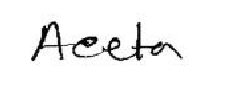

In [ ]:
cv2.imread(sample_path)

In [ ]:
train_df["MEDICINE_NAME"].value_counts()

,count
MEDICINE_NAME,
Aceta,40
Ace,40
Alatrol,40
Amodis,40
Atrizin,40
...,...
Telfast,40
Tridosil,40
Trilock,40


In [ ]:
from sklearn.model_selection import train_test_split

train_data, val_data = train_test_split(
    train_df,
    test_size=0.20,
    random_state=42,
    stratify=train_df["MEDICINE_NAME"]
)